In [36]:
import json
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = pathlib.Path("..")
RESULTS_DIR = ROOT / "results" / "linguistic_nli" / "message"
DIMS = ["conviction", "anchoring", "dialogic"]

In [37]:
rows = []
for f in RESULTS_DIR.glob("**/*.json"):
    rows.extend(json.loads(f.read_text()))
df = pd.DataFrame(rows)
print(f"{len(df):,} rows | topologies: {df['topology'].value_counts().to_dict()}")
df.head()

75,504 rows | topologies: {'star': 38992, 'fc': 36512}


,dataset,topology,W,qid,rep_idx,round,agent_idx,agent_id,conviction,anchoring,dialogic
0,gpqa,star,1,84,0,0,0,0,4,3,5
1,gpqa,star,1,84,0,1,0,0,4,3,5
2,gpqa,star,1,84,0,0,1,1,4,3,5
3,gpqa,star,1,84,0,1,1,1,4,4,5
4,gpqa,star,1,84,0,0,2,2,4,3,5


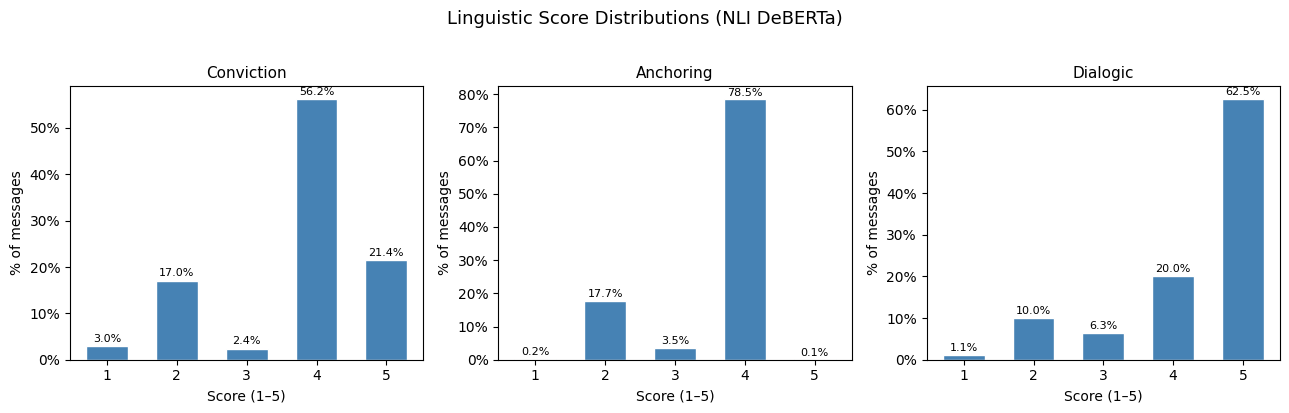

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.suptitle("Linguistic Score Distributions (NLI DeBERTa)", fontsize=13, y=1.02)

for ax, dim in zip(axes, DIMS):
    counts = df[dim].value_counts().sort_index()
    pct = counts / counts.sum() * 100
    bars = ax.bar(pct.index, pct.values, color="steelblue", edgecolor="white", width=0.6)
    ax.set_title(dim.capitalize(), fontsize=11)
    ax.set_xlabel("Score (1–5)")
    ax.set_ylabel("% of messages")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    for bar, v in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

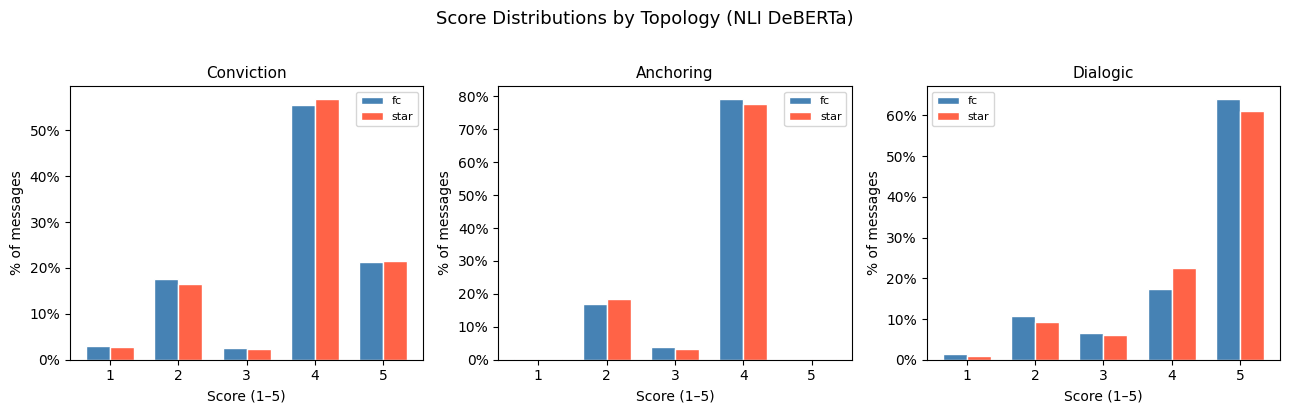

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.suptitle("Score Distributions by Topology (NLI DeBERTa)", fontsize=13, y=1.02)

colors = {"fc": "steelblue", "star": "tomato"}
width = 0.35
topos = sorted(df["topology"].unique())

for ax, dim in zip(axes, DIMS):
    for i, topo in enumerate(topos):
        sub = df[df["topology"] == topo]
        counts = sub[dim].value_counts().reindex([1,2,3,4,5], fill_value=0)
        pct = counts / counts.sum() * 100
        offset = (i - len(topos) / 2 + 0.5) * width
        ax.bar([x + offset for x in pct.index], pct.values,
               width=width, label=topo, color=colors.get(topo), edgecolor="white")
    ax.set_title(dim.capitalize(), fontsize=11)
    ax.set_xlabel("Score (1–5)")
    ax.set_ylabel("% of messages")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_58763/736881574.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(ws))


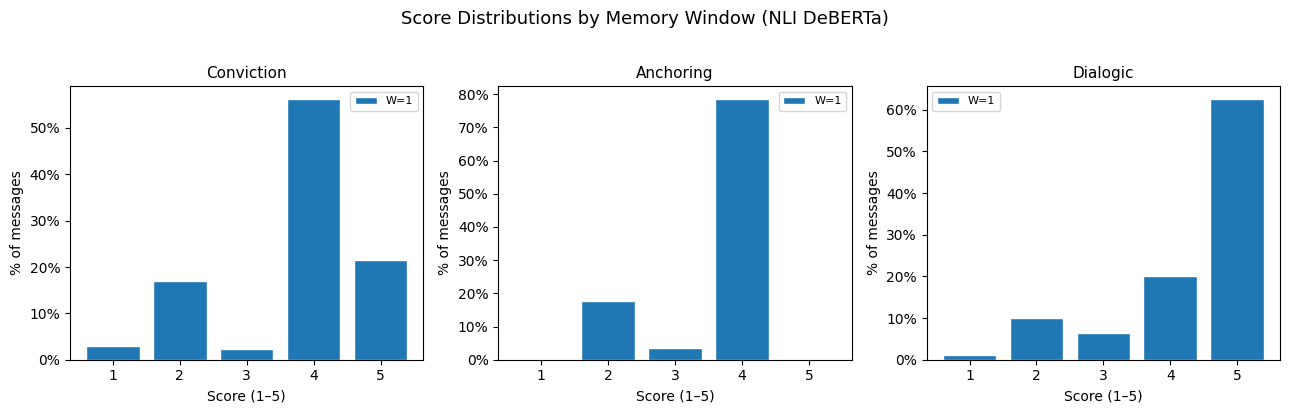

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.suptitle("Score Distributions by Memory Window (NLI DeBERTa)", fontsize=13, y=1.02)

ws = sorted(df["W"].unique())
cmap = plt.cm.get_cmap("tab10", len(ws))
colors_w = {w: cmap(i) for i, w in enumerate(ws)}
width = 0.8 / max(len(ws), 1)

for ax, dim in zip(axes, DIMS):
    for i, w in enumerate(ws):
        sub = df[df["W"] == w]
        counts = sub[dim].value_counts().reindex([1,2,3,4,5], fill_value=0)
        pct = counts / counts.sum() * 100
        offset = (i - len(ws) / 2 + 0.5) * width
        ax.bar([x + offset for x in pct.index], pct.values,
               width=width, label=f"W={w}", color=colors_w[w], edgecolor="white")
    ax.set_title(dim.capitalize(), fontsize=11)
    ax.set_xlabel("Score (1–5)")
    ax.set_ylabel("% of messages")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

/var/folders/92/yglwvnmx2bsg0b42jym1s8lh0000gn/T/ipykernel_58763/2914342082.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, len(groups))


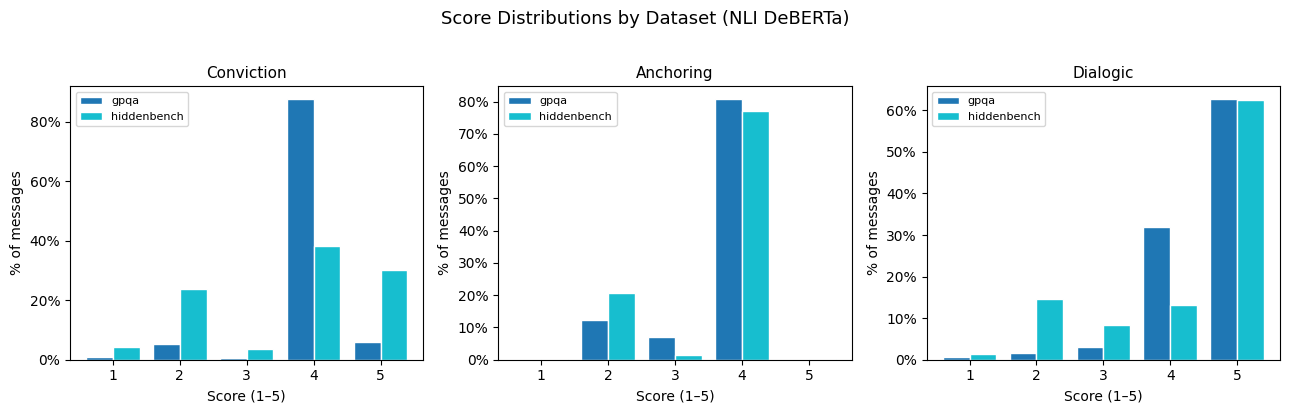

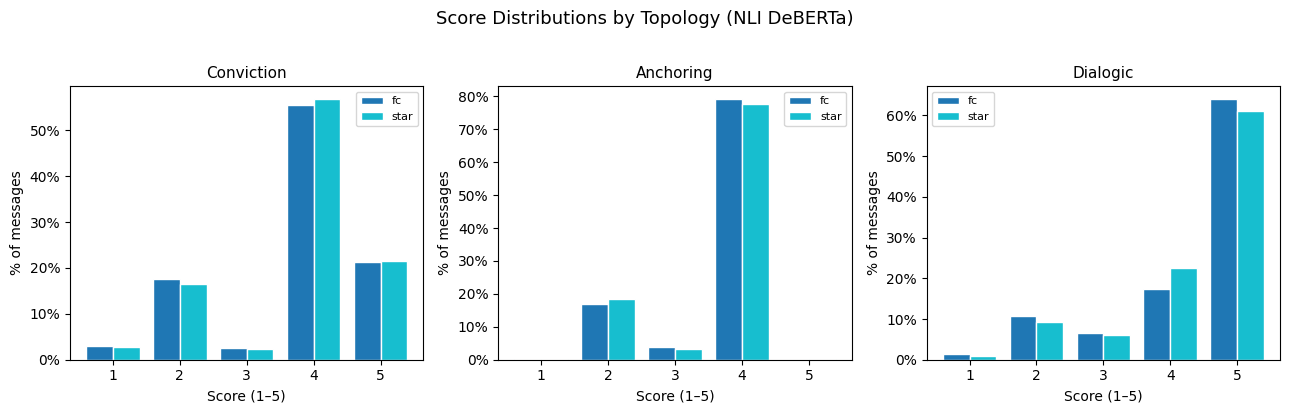

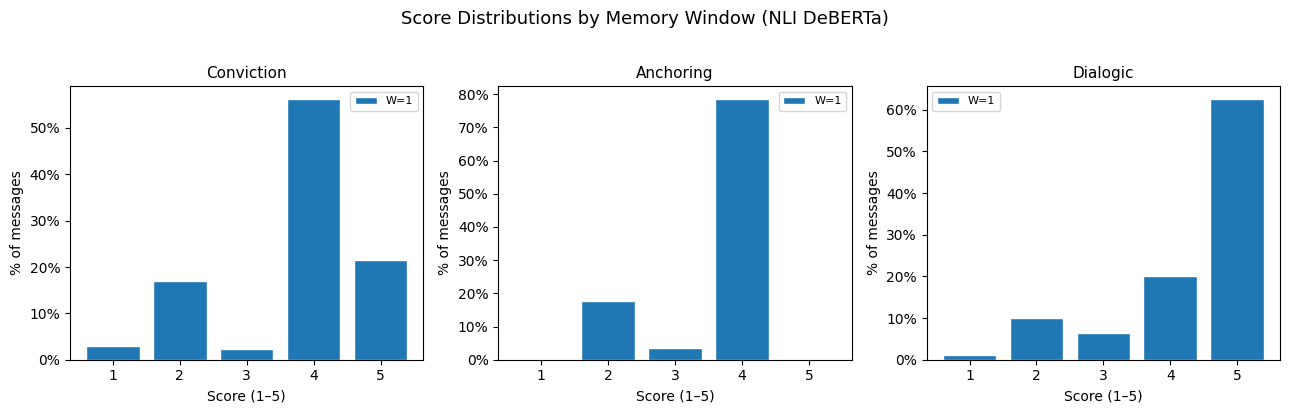

In [41]:
def plot_by_group(df, group_col, label_fn, cmap_name="tab10", title_suffix=""):
    groups = sorted(df[group_col].unique())
    cmap = plt.cm.get_cmap(cmap_name, len(groups))
    colors_g = {g: cmap(i) for i, g in enumerate(groups)}
    width = 0.8 / max(len(groups), 1)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
    fig.suptitle(f"Score Distributions by {title_suffix} (NLI DeBERTa)", fontsize=13, y=1.02)
    for ax, dim in zip(axes, DIMS):
        for i, g in enumerate(groups):
            sub = df[df[group_col] == g]
            counts = sub[dim].value_counts().reindex([1,2,3,4,5], fill_value=0)
            pct = counts / counts.sum() * 100
            offset = (i - len(groups) / 2 + 0.5) * width
            ax.bar([x + offset for x in pct.index], pct.values,
                   width=width, label=label_fn(g), color=colors_g[g], edgecolor="white")
        ax.set_title(dim.capitalize(), fontsize=11)
        ax.set_xlabel("Score (1–5)")
        ax.set_ylabel("% of messages")
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_by_group(df, "dataset",  lambda g: g,       title_suffix="Dataset")
plot_by_group(df, "topology", lambda g: g,       title_suffix="Topology")
plot_by_group(df, "W",        lambda g: f"W={g}", title_suffix="Memory Window")

In [42]:
print("=== Summary statistics ===")
print(df[DIMS].describe().round(2))
print("\n=== Value counts ===")
for dim in DIMS:
    vc = df[dim].value_counts().sort_index()
    pct = (vc / vc.sum() * 100).round(1)
    print(f"\n{dim}:")
    print(pd.DataFrame({"n": vc, "%": pct}))

=== Summary statistics ===
       conviction  anchoring  dialogic
count    75504.00   75504.00  75504.00
mean         3.76       3.61      4.33
std          1.06       0.78      1.04
min          1.00       1.00      1.00
25%          4.00       4.00      4.00
50%          4.00       4.00      5.00
75%          4.00       4.00      5.00
max          5.00       5.00      5.00

=== Value counts ===

conviction:
                n     %
conviction             
1            2238   3.0
2           12863  17.0
3            1807   2.4
4           42412  56.2
5           16184  21.4

anchoring:
               n     %
anchoring             
1            138   0.2
2          13390  17.7
3           2677   3.5
4          59245  78.5
5             54   0.1

dialogic:
              n     %
dialogic             
1           855   1.1
2          7545  10.0
3          4785   6.3
4         15124  20.0
5         47195  62.5
